# **ANN**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf

In [3]:
from tensorflow.keras.models import Sequential #build a neural network layer-by-layer in a linear fashion
from tensorflow.keras.layers import Dense #Fully connected layer (every neuron connects to every neuron in the next layer)
from tensorflow.keras.layers import Dropout #Randomly drops some neurons during training to prevent overfitting
from tensorflow.keras.utils import to_categorical #Converts class labels (like 0, 1, 2) into one-hot encoded format (e.g., [1,0,0], [0,1,0])

In [4]:
df = sns.load_dataset('iris')

In [5]:
df.head ()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

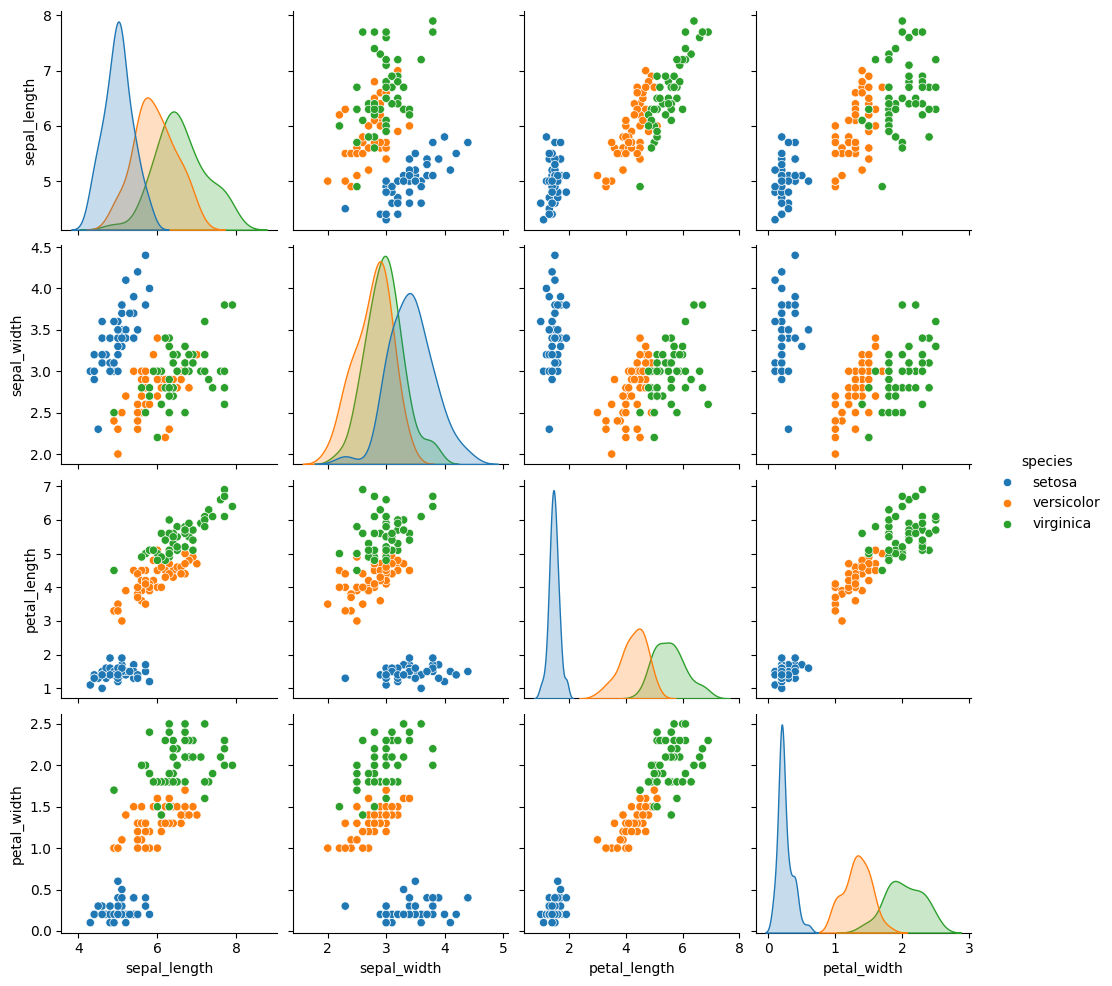

In [7]:
sns.pairplot(df, hue='species')

In [8]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [9]:
X = df.drop(columns= ['species'], axis=1)
Y = df['species']

In [10]:
encoder = LabelEncoder()

In [11]:
y_int = encoder.fit_transform(Y)
y_int

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.33, random_state=42)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [14]:
per = Perceptron (max_iter = 1000, random_state=42)
per.fit(X_train_scaled, y_train)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,42


In [15]:
y_pred_percep = per.predict(X_test_scaled)

In [16]:
accuracy_score (y_test, y_pred_percep)

0.68

In [17]:
print(classification_report(y_test,y_pred_percep))

              precision    recall  f1-score   support

      setosa       0.76      0.68      0.72        19
  versicolor       0.45      0.33      0.38        15
   virginica       0.73      1.00      0.84        16

    accuracy                           0.68        50
   macro avg       0.65      0.67      0.65        50
weighted avg       0.66      0.68      0.66        50



In [18]:
y_train_encoded = encoder.fit_transform(y_train)
y_train_cat = to_categorical(y_train_encoded, num_classes=3)
y_test_encoded = encoder.transform(y_test)
y_test_cat = to_categorical(y_test_encoded, num_classes=3)

In [19]:
y_train_cat

array([[0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0

In [20]:
model = Sequential ([
    Dense (16, input_dim=4, activation='relu'),
    Dense (8, activation='relu'),
    Dense (3, activation='softmax')
])

In [21]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [22]:
history = model.fit (X_train_scaled, y_train_cat, epochs=100, batch_size=8, validation_split=0.2, verbose=1)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2125 - loss: 1.3072 - val_accuracy: 0.2500 - val_loss: 1.2132
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2375 - loss: 1.2372 - val_accuracy: 0.2500 - val_loss: 1.1492
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3625 - loss: 1.1751 - val_accuracy: 0.5500 - val_loss: 1.0972
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4875 - loss: 1.1211 - val_accuracy: 0.7000 - val_loss: 1.0492
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5500 - loss: 1.0710 - val_accuracy: 0.7000 - val_loss: 1.0062
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5750 - loss: 1.0238 - val_accuracy: 0.7000 - val_loss: 0.9699
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5750 - loss: 0.9808 - val_accuracy: 0.7000 - val_loss: 0.9328
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5750 - loss: 0.9399 - val_accuracy: 0.6500 - 

In [23]:
loss, acc = model.evaluate(X_test_scaled, y_test_cat, verbose=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9800 - loss: 0.0830


In [24]:
print(acc)

0.9800000190734863


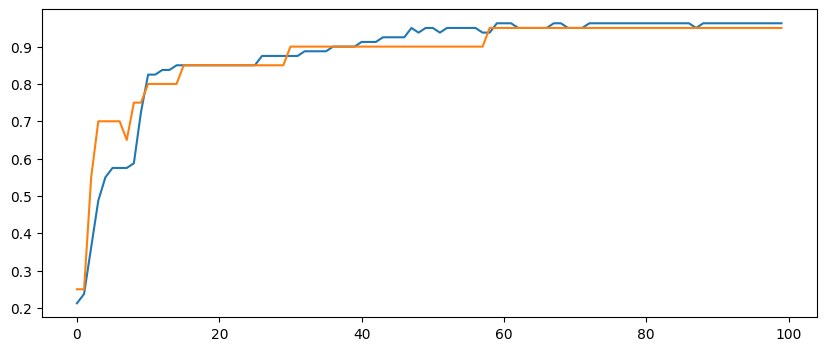

In [25]:
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'], label='val Acc')

# **CNN**

In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [27]:
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.
from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them
from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting
from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models

In [28]:
df = pd.read_csv("train.csv")
df_test = pd.read_csv("mnist_test.csv")

In [29]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
df.shape

(42000, 785)

In [31]:
df.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)

In [32]:
df_test.columns

Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=785)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [34]:
df.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

In [35]:
X_train = df.drop("label", axis=1).values
y_train = df["label"].values
X_test = df_test.drop("label", axis=1).values
y_test = df_test["label"].values

In [36]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

In [37]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [38]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation="softmax")
])

In [39]:
perceptron.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])

In [40]:
history_percp = perceptron.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7905 - loss: 0.8855 - val_accuracy: 0.8706 - val_loss: 0.5377
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8732 - loss: 0.4996 - val_accuracy: 0.8874 - val_loss: 0.4342
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8849 - loss: 0.4329 - val_accuracy: 0.8970 - val_loss: 0.3928
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8918 - loss: 0.4001 - val_accuracy: 0.9015 - val_loss: 0.3685
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8966 - loss: 0.3792 - val_accuracy: 0.9042 - val_loss: 0.3525


In [41]:
acc_percp = perceptron.evaluate(X_test_img, y_test_cat, verbose=0)[1]
acc_percp

0.90420001745224

In [42]:
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

In [43]:
ann.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [44]:
history_ann = ann.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9180 - loss: 0.2813 - val_accuracy: 0.9588 - val_loss: 0.1358
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9648 - loss: 0.1174 - val_accuracy: 0.9757 - val_loss: 0.0823
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9756 - loss: 0.0805 - val_accuracy: 0.9775 - val_loss: 0.0752
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9808 - loss: 0.0607 - val_accuracy: 0.9866 - val_loss: 0.0473
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9849 - loss: 0.0462 - val_accuracy: 0.9824 - val_loss: 0.0576


In [45]:
acc_ann = ann.evaluate(X_test_img, y_test_cat, verbose=0)[1]
acc_ann

0.9824000000953674

In [46]:
X_train_cnn = X_train.reshape(-1, 28, 28,1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [47]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

In [48]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [49]:
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_cnn, y_test_cat), verbose=1)

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9259 - loss: 0.2439 - val_accuracy: 0.9813 - val_loss: 0.0566
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9744 - loss: 0.0869 - val_accuracy: 0.9897 - val_loss: 0.0313
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9808 - loss: 0.0633 - val_accuracy: 0.9914 - val_loss: 0.0276
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9840 - loss: 0.0518 - val_accuracy: 0.9945 - val_loss: 0.0185
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9867 - loss: 0.0425 - val_accuracy: 0.9937 - val_loss: 0.0191


In [50]:
acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]
acc_cnn

0.9937000274658203

In [51]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

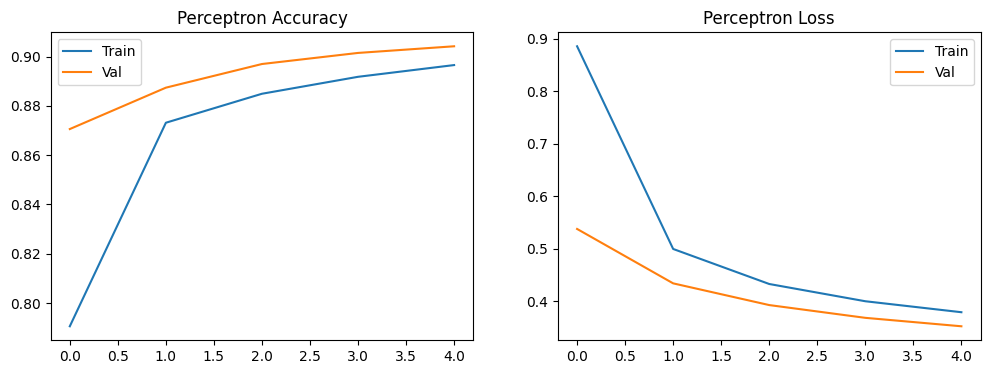

In [52]:
plot_training(history_percp, "Perceptron")

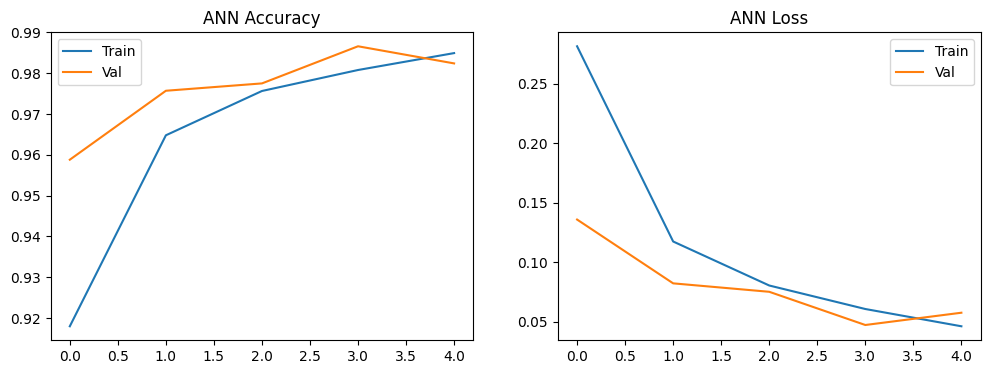

In [53]:
plot_training(history_ann, "ANN")

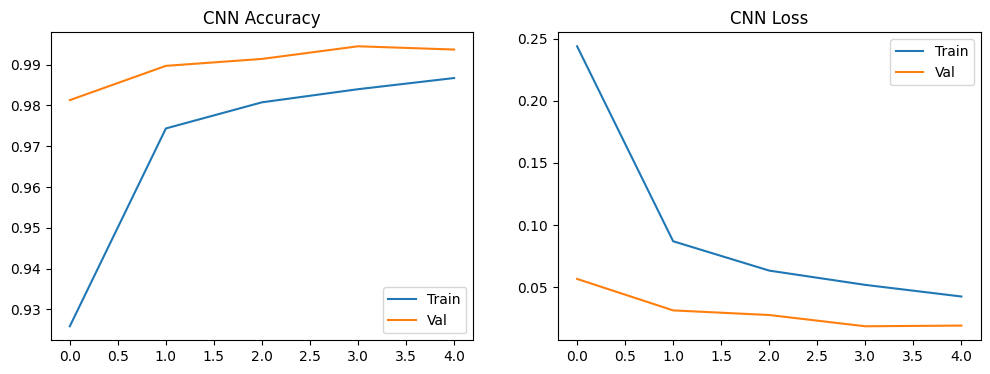

In [54]:
plot_training(history_cnn, "CNN")

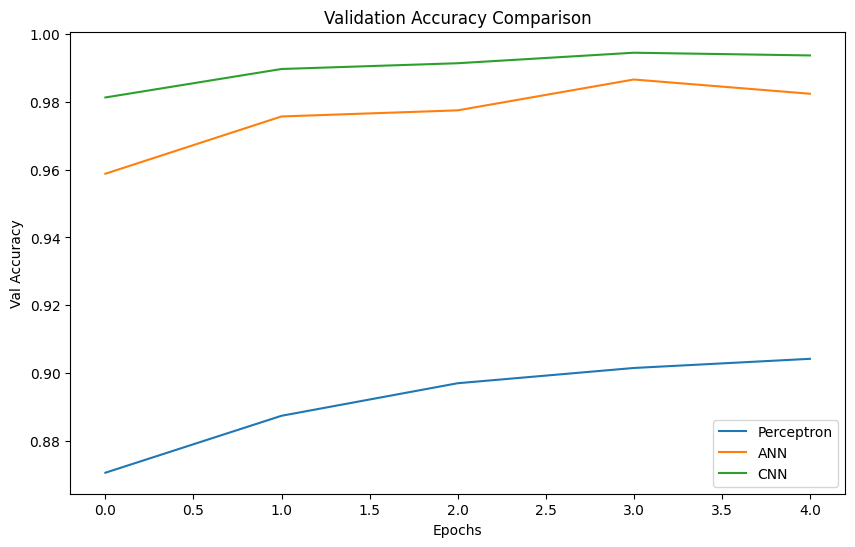

In [55]:
plt.figure(figsize=(10,6))
plt.plot(history_percp.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [56]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


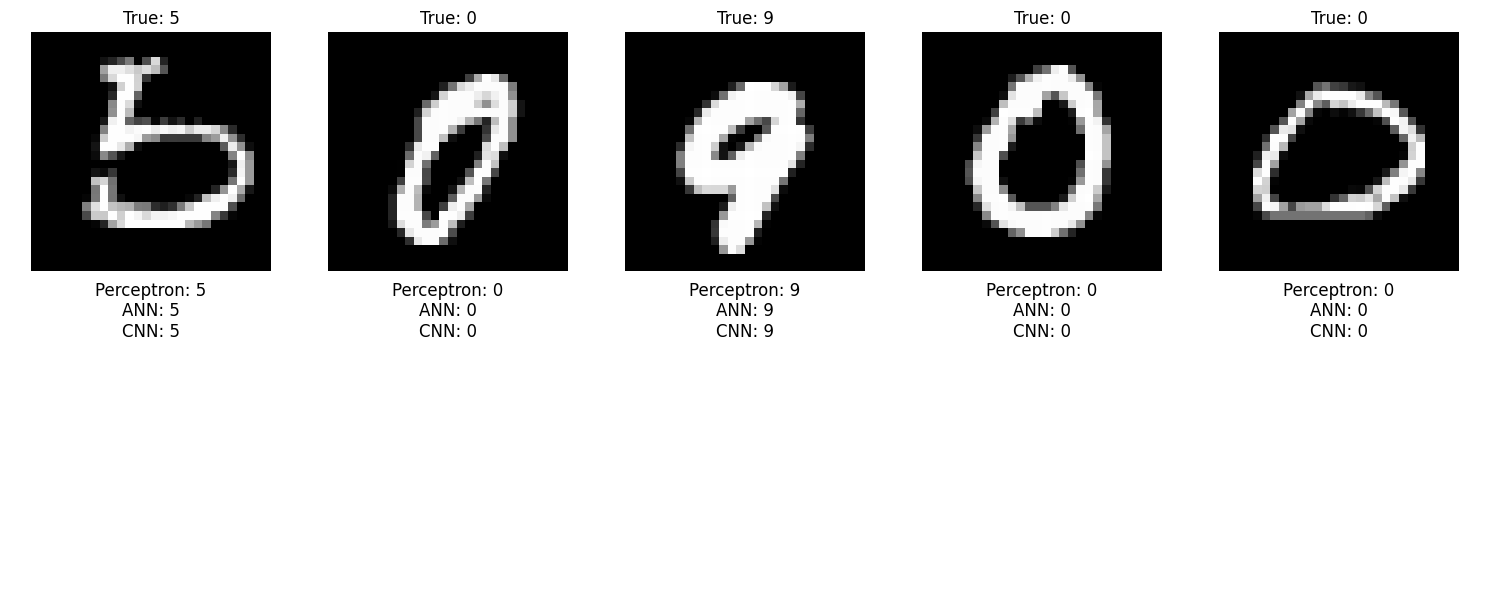

In [57]:
show_side_by_side([perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 5)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


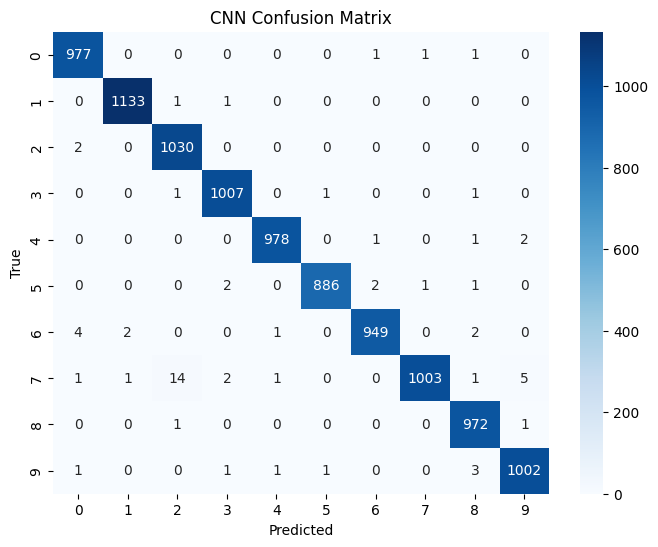

In [58]:
y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

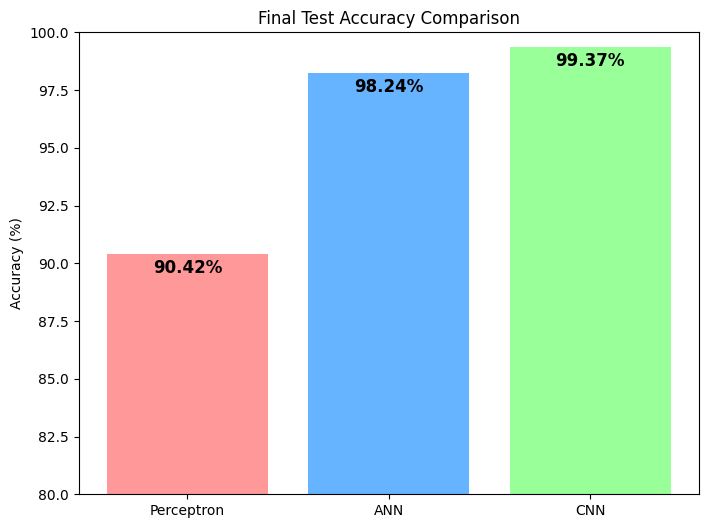

In [59]:
final_accs = [acc_percp*100, acc_ann*100, acc_cnn*100]
models = ["Perceptron", "ANN", "CNN"]
plt.figure(figsize=(8,6))
bars = plt.bar(models, final_accs, color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(80, 100)
plt.show()

# **RNN**

In [60]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense

In [61]:
sentences = [
 "I love this product",
 "This movie made me smile",
 "Service was friendly and quick",
 "Today felt bright and happy",
 "This is the best day",
 "Absolutely fantastic experience",
 "I enjoyed every single moment",
 "Great job, well done",
 "The food tasted delicious",
 "Totally recommend to everyone",
 "Very satisfied with results",
 "This worked better than expected",
 "Amazing quality and value",
 "Such a pleasant surprise",
 "I feel positive about this",
 "I hate this product",
 "This movie bored me",
 "Service was rude and slow",
 "Today was cold and lonely",
 "This is the worst day",
 "Terrible experience overall",
 "I regret buying this",
 "Very disappointed with results",
 "The food tasted awful",
 "Do not recommend this",
 "It broke after one use",
 "Not worth the money",
 "Utterly frustrating and annoying",
 "I feel negative about this",
 "Such a waste of time",
]
labels = [1]*15 + [0]*15
labels = np.array(labels)

In [62]:
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

In [63]:
vocab_size = 2000
tok  = Tokenizer(num_words = vocab_size,oov_token = "<OOV>") #oov out of vocabulary
tok.fit_on_texts(sentences)
seqs = tok.texts_to_sequences(sentences)
maxlen = max(len(s) for s in seqs)
X = pad_sequences(seqs,maxlen = maxlen,padding = 'post')
y = labels

In [64]:
maxlen

5

In [65]:
X[0]

array([ 3, 26,  2,  7,  0], dtype=int32)

In [66]:
embed_dim = 16
rnn_units = 8

In [67]:
inp = Input(shape= (maxlen,),dtype="int32",name = 'input')
x = Embedding(input_dim=vocab_size,output_dim=embed_dim,mask_zero=True,name = 'embed')(inp)
rnn = SimpleRNN(units = rnn_units, return_sequences = False,return_state= False,name = 'simple_rnn')
x_last = rnn(x)
out = Dense(1,activation='sigmoid',name = 'out')(x_last)
model = Model(inputs =inp,outputs = out)
model.compile(optimizer='adam',loss = 'binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 5)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed (Embedding)   │ (None, 5, 16)     │     32,000 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 5)         │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 8)         │        200 │ embed[0][0],      │
│ (SimpleRNN)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out (Dense)         │ (None, 1)         │          9 │ simple_rnn[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,209 (125.82 KB)

 Trainable params: 32,209 (125.82 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
model.fit(X,y,epochs= 25,batch_size = 8,verbose = 1)

Epoch 1/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5333 - loss: 0.6822
Epoch 2/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7000 - loss: 0.6641 
Epoch 3/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7667 - loss: 0.6479 
Epoch 4/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8000 - loss: 0.6302 
Epoch 5/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9000 - loss: 0.6136 
Epoch 6/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9000 - loss: 0.5968 
Epoch 7/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9333 - loss: 0.5791 
Epoch 8/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9333 - loss: 0.5598 
Epoch 9/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9333 - loss: 0.5395 
Epoch 10/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9333 - loss: 0.5194 
Epoch 11/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9333 - loss: 0.4982 
Epoch 12/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9667 - loss: 0.4768 
Ep

In [69]:
model.evaluate(X, y)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 1.0000 - loss: 0.2003


[0.20025113224983215, 1.0]

In [70]:
pred = model.predict(X) # Make Predictions
print(pred[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
[[0.7170816 ]
 [0.92587817]
 [0.80032873]
 [0.8751714 ]
 [0.73272777]]


In [71]:
pred_labels = (pred > 0.5).astype(int) # Convert probabilities into labels:
print(pred_labels[:5])

[[1]
 [1]
 [1]
 [1]
 [1]]


In [72]:
history = model.fit(X, y,epochs=25,batch_size=8,verbose=1)

Epoch 1/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.1967 
Epoch 2/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.1819 
Epoch 3/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.1705 
Epoch 4/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.1575 
Epoch 5/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.1480 
Epoch 6/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.1379 
Epoch 7/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1291 
Epoch 8/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1213 
Epoch 9/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.1139 
Epoch 10/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.1073 
Epoch 11/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.1007 
Epoch 12/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0953 
E

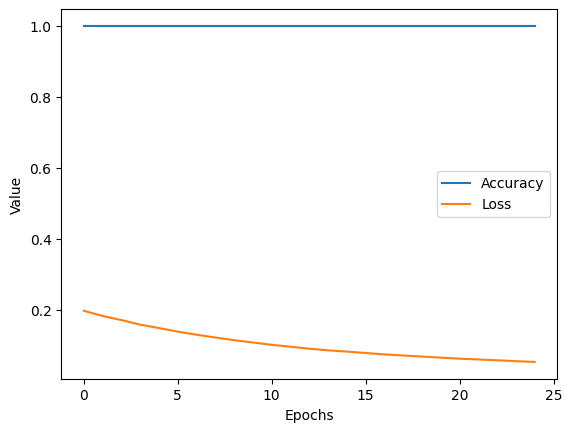

In [73]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.legend(['Accuracy', 'Loss'])
plt.show()

In [74]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 5)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed (Embedding)   │ (None, 5, 16)     │     32,000 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 5)         │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 8)         │        200 │ embed[0][0],      │
│ (SimpleRNN)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out (Dense)         │ (None, 1)         │          9 │ simple_rnn[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 96,629 (377.46 KB)

 Trainable params: 32,209 (125.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64,420 (251.64 KB)

In [75]:
#Inspect RNN Hidden States

intermediate_model = Model(inputs=model.inputs, outputs=[model.get_layer('embed').output, model.get_layer('simple_rnn').output])

In [76]:
from tensorflow.keras.layers import SimpleRNN as SRNN
seq_inp = Input(shape=(maxlen,), dtype='int32')
seq_emb = model.get_layer('embed')(seq_inp)  # reuse trained embedding

# Create RNN with return_sequences=True
rnn_seq = SRNN(units=rnn_units, return_sequences=True, name='rnn_seq')

# DO NOT CALL build() manually
seq_hidden = rnn_seq(seq_emb)  # builds automatically

# Copy trained RNN weights
try:
    trained_weights = model.get_layer('simple_rnn').get_weights()
    rnn_seq.set_weights(trained_weights)
    print("Copied RNN weights into sequence-inspection RNN.")
except Exception as e:
    print("Could not copy weights automatically:", e)

inspect_model = Model(inputs=seq_inp, outputs=seq_hidden)

# Inspect
idx = 0
example_seq = X[idx:idx+1]  # shape (1, maxlen)
hidden_seq = inspect_model.predict(example_seq)

print("Sentence:", sentences[idx])
print("Token ids:", example_seq)
print("Hidden states per timestep shape:", hidden_seq.shape)
print("Hidden states (timesteps x units):")
print(np.round(hidden_seq[0], 3))

Copied RNN weights into sequence-inspection RNN.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
Sentence: I love this product
Token ids: [[ 3 26  2  7  0]]
Hidden states per timestep shape: (1, 5, 8)
Hidden states (timesteps x units):
[[ 0.009  0.126  0.11  -0.059 -0.03  -0.013 -0.038 -0.121]
 [ 0.361  0.004  0.356 -0.08  -0.227 -0.147 -0.087 -0.394]
 [-0.312  0.413  0.31  -0.138 -0.035  0.649 -0.575  0.092]
 [ 0.667 -0.716 -0.523  0.679 -0.581 -0.44   0.45   0.614]
 [ 0.667 -0.716 -0.523  0.679 -0.581 -0.44   0.45   0.614]]


# **LSTM**

In [77]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [78]:
df = pd.read_csv("qoute_dataset.csv")
df.head()

,quote,Author
0,“The world as we have created it is a process ...,Albert Einstein
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling
2,“There are only two ways to live your life. On...,Albert Einstein
3,"“The person, be it gentleman or lady, who has ...",Jane Austen
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe


In [79]:
df.shape

(3038, 2)

In [80]:
quotes = df['quote']
quotes.head()

0    “The world as we have created it is a process ...
1    “It is our choices, Harry, that show what we t...
2    “There are only two ways to live your life. On...
3    “The person, be it gentleman or lady, who has ...
4    “Imperfection is beauty, madness is genius and...
Name: quote, dtype: object

In [81]:
quotes = quotes.str.lower()

In [82]:
import string
translator = str.maketrans('', '', string.punctuation) #Creates a translation table for removing punctuation
quotes = quotes.apply(lambda x: x.translate(translator)) #Removes punctuation from every sentence in quotes.

In [83]:
quotes.head()

0    “the world as we have created it is a process ...
1    “it is our choices harry that show what we tru...
2    “there are only two ways to live your life one...
3    “the person be it gentleman or lady who has no...
4    “imperfection is beauty madness is genius and ...
Name: quote, dtype: object

In [84]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [85]:
vocab_size = 10000
tokinizer = Tokenizer(num_words=vocab_size)
tokinizer.fit_on_texts(quotes)

In [86]:
word_index = tokinizer.word_index
print(len(word_index))
list(word_index.items())[:10]

8978


[('the', 1),
 ('you', 2),
 ('to', 3),
 ('and', 4),
 ('a', 5),
 ('i', 6),
 ('is', 7),
 ('of', 8),
 ('that', 9),
 ('it', 10)]

In [87]:
sequence = tokinizer.texts_to_sequences(quotes)

In [88]:
for i in range(6):
  print(quotes[i])

“the world as we have created it is a process of our thinking it cannot be changed without changing our thinking”
“it is our choices harry that show what we truly are far more than our abilities”
“there are only two ways to live your life one is as though nothing is a miracle the other is as though everything is a miracle”
“the person be it gentleman or lady who has not pleasure in a good novel must be intolerably stupid”
“imperfection is beauty madness is genius and its better to be absolutely ridiculous than absolutely boring”
“try not to become a man of success rather become a man of value”


In [89]:
for i in range(6):
  print(sequence[i])

[713, 62, 29, 19, 16, 946, 10, 7, 5, 1156, 8, 70, 293, 10, 145, 12, 809, 104, 752, 70, 2461]
[947, 7, 70, 871, 373, 9, 433, 21, 19, 465, 14, 294, 52, 54, 70, 3676]
[1337, 14, 53, 201, 714, 3, 81, 15, 36, 37, 7, 29, 329, 93, 7, 5, 1157, 1, 101, 7, 29, 329, 126, 7, 5, 3677]
[713, 116, 12, 10, 2462, 32, 1043, 30, 82, 13, 601, 11, 5, 74, 1338, 119, 12, 2463, 3678]
[3679, 7, 313, 753, 7, 638, 4, 43, 144, 3, 12, 682, 1339, 54, 682, 3680]
[3681, 13, 3, 202, 5, 90, 8, 434, 279, 202, 5, 90, 8, 3682]


In [90]:
X = []
y = []
for seq in sequence:
  for i in range(1,len(seq)):
    input_seq = seq[:i]
    output_seq = seq[i]
    X.append(input_seq)
    y.append(output_seq)

In [91]:
len(X)

85271

In [92]:
len(y)

85271

In [93]:
max_len = max(len(x) for x in X)
print(max_len)

745


In [94]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_padded = pad_sequences(X, maxlen=max_len, padding='pre')

In [95]:
y = np.array(y)
X_padded.shape

(85271, 745)

In [96]:
from tensorflow.keras.utils import to_categorical
y_one_hot = to_categorical(y, num_classes=vocab_size)
y.shape

(85271,)

In [97]:
y_one_hot.shape

(85271, 10000)

In [98]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,LSTM, Dense
embedding_dim = 50
rnn_units1 = 128
rnn_model1 = Sequential()
rnn_model1.add(
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len)
)
rnn_model1.add(SimpleRNN(units=rnn_units))
rnn_model1.add(Dense(units=vocab_size, activation='softmax'))

In [99]:
rnn_model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
rnn_model1.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [100]:
lstm_model = Sequential()
lstm_model.add(
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len)
)
lstm_model.add(LSTM(units=rnn_units))
lstm_model.add(Dense(units=vocab_size, activation='softmax'))
lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [101]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
history_rnn = rnn_model1.fit(X_padded, y_one_hot, epochs = 100, batch_size = 128, validation_split=0.1, callbacks=[early_stop])

Epoch 1/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 94s 153ms/step - accuracy: 0.0358 - loss: 7.3963 - val_accuracy: 0.0365 - val_loss: 6.7341
Epoch 2/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 90s 150ms/step - accuracy: 0.0389 - loss: 6.5269 - val_accuracy: 0.0365 - val_loss: 6.6727
Epoch 3/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 95s 158ms/step - accuracy: 0.0389 - loss: 6.4430 - val_accuracy: 0.0365 - val_loss: 6.6662
Epoch 4/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 651s 1s/step - accuracy: 0.0397 - loss: 6.3855 - val_accuracy: 0.0381 - val_loss: 6.6585
Epoch 5/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 87s 144ms/step - accuracy: 0.0409 - loss: 6.3359 - val_accuracy: 0.0380 - val_loss: 6.6524
Epoch 6/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 90s 149ms/step - accuracy: 0.0418 - loss: 6.2912 - val_accuracy: 0.0401 - val_loss: 6.6323
Epoch 7/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 117s 196ms/step - accuracy: 0.0462 - loss: 6.2324 - val_accuracy: 0.0519 - val_loss: 6.6065
Epoch 8/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 89s 149ms/step - accuracy: 0.0512 - 

In [102]:
lstm_model.save("lstm_model.h5")

In [103]:
index_to_word = {}
for word, index in word_index.items():
  index_to_word[index] = word

In [104]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
def predictor(model,tokenizer,text,max_len):
  text = text.lower()

  seq = tokenizer.texts_to_sequences([text])[0]
  seq = pad_sequences([seq], maxlen=max_len, padding='pre')

  pred = model.predict(seq,verbose = 0)
  pred_index = np.argmax(pred)
  return index_to_word[pred_index]

In [105]:
seed_text = "what are you"
next_word = predictor(lstm_model,tokinizer,seed_text,max_len)
print(next_word)

above


In [106]:
def generate_text(model,tokenizer,seed_text,max_len,n_words):
  for _ in range(n_words):
    next_word = predictor(model,tokenizer,seed_text,max_len)
    if next_word == "":
      break
    seed_text += " " + next_word
  return seed_text
seed = "are you a "
generate_text = generate_text(lstm_model,tokinizer,seed,max_len,10)
print(generate_text)

are you a  greater greater morepresently fascinates man nuances الحقيقة، nuances canst haven


In [109]:
import pickle
with open("tokenizer.pkl", "wb") as f:
  pickle.dump(tokinizer, f)

In [110]:
with open("max_len.pkl", "wb") as f:
  pickle.dump(max_len, f)

# **GRU**